<a href="https://colab.research.google.com/github/AnanyaUp/ANN-Deep-Learning/blob/main/Custom_Dataloader_and_Simple_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [119]:
import torch
torch.__version__

'2.6.0+cu124'

In [120]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.datasets import make_regression
from sklearn import metrics
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.datasets as datasets
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import transforms
from PIL import Image
from tqdm import tqdm

# Hiding the warnings
import warnings
warnings.filterwarnings('ignore')

# **Custom Data Loader (Image Data) using Pytorch**

In [122]:
# Path to dataset
dataset_path = "/content/drive/MyDrive/animals"

# Image transformations
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.125, 0.125, 0.125])
])

class CatsDogsDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []

        # Load all images from the "cats" folder
        cat_folder = os.path.join(root_dir, "cat")
        for file in os.listdir(cat_folder):
            if file.endswith(('jpg', 'png', 'jpeg')):
                self.images.append(os.path.join(cat_folder, file))
                self.labels.append(0)

        # Load all images from the "dogs" folder
        dog_folder = os.path.join(root_dir, "dog")
        for file in os.listdir(dog_folder):
            if file.endswith(('jpg', 'png', 'jpeg')):
                self.images.append(os.path.join(dog_folder, file))
                self.labels.append(1)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert("RGB")

        # Apply transformations if any
        if self.transform:
            image = self.transform(image)

        # Convert label to tensor
        label = torch.tensor(label, dtype=torch.long)
        return image, label

# Instantiate Dataset
dataset = CatsDogsDataset(dataset_path, transform=transform)

# DataLoader
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# Test the DataLoader
for images, labels in dataloader:
    print(f"Batch size: {images.shape}, Labels: {labels}")
    break

Batch size: torch.Size([64, 3, 256, 256]), Labels: tensor([1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1,
        0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1,
        0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1])


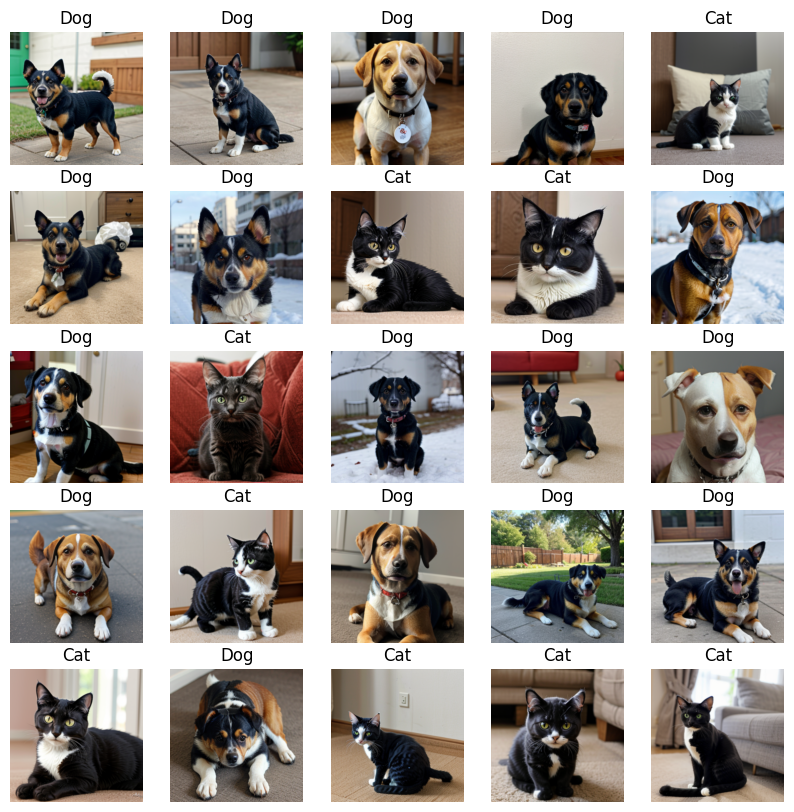

In [123]:
# Load one batch from DataLoader
images, labels = next(iter(dataloader))

class_names = ["Cat", "Dog"]

plt.figure(figsize=(10, 10))

# Visualize 25 images (5x5 grid)
for i in range(25):
    plt.subplot(5, 5, i+1)
    img = images[i].permute(1, 2, 0)  # Change tensor shape from (C, H, W) -> (H, W, C)

    # Reverse normalization
    img = img * 0.125 + 0.5

    # Plot the image
    plt.imshow(img.numpy())
    plt.title(f"{class_names[labels[i].item()]}")
    plt.axis("off")

plt.show()

# **Applying CNN for image classification**

In [124]:
# Importing data using data loader
for i in images:
  print("Image = ", i.shape)

Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size(

In [125]:
labels

tensor([1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0,
        0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0])

In [126]:
# Define CNN model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.fc1 = nn.Linear(32 * 64 * 64, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

In [127]:
# Get the number of samples in 'images'
num_samples = images.shape[0]

In [128]:
# Create 'labels' with the correct size
labels = torch.tensor([1] * num_samples, dtype=torch.float32).unsqueeze(1)

In [129]:
# Now create the TensorDataset
df = TensorDataset(images, labels)
dataloader = DataLoader(df, batch_size=4, shuffle=True)

In [130]:
# Model, loss, and optimizer
model = CNN()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [131]:
# Training Loop
num_epochs = 3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
for epoch in range(num_epochs):
    total_loss = 0.0
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for batch in progress_bar:
        inputs, targets = batch
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({'Loss': loss.item()})

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}")



Epoch 1/3: 100%|██████████| 16/16 [00:07<00:00,  2.02it/s, Loss=0]


Epoch 1/3, Loss: 0.036882


Epoch 2/3: 100%|██████████| 16/16 [00:07<00:00,  2.24it/s, Loss=0]


Epoch 2/3, Loss: 0.000000


Epoch 3/3: 100%|██████████| 16/16 [00:07<00:00,  2.14it/s, Loss=0]

Epoch 3/3, Loss: 0.000000


In [132]:
with torch.no_grad():
    test_output = model(images)
    predicted = (test_output > 0.5).float()
    print("Predictions:", predicted.view(-1).tolist())

Predictions: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


In [144]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load MNIST dataset
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Create DataLoaders for batch processing
train_loader = DataLoader(train_dataset, batch_size=28, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=28, shuffle=False)

# Check dataset size
print(f"Training Samples: {len(train_dataset)}, Testing Samples: {len(test_dataset)}")
print("Training Data : ",train_dataset)
print("Testing Data : ",test_dataset)

Training Samples: 60000, Testing Samples: 10000
Training Data :  Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )
Testing Data :  Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )


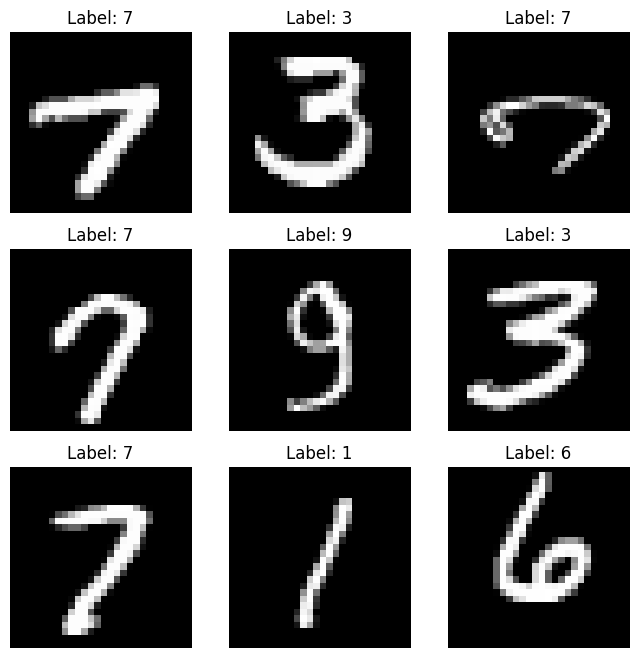

In [145]:
# Visualizing some samples
examples = iter(train_loader)
images, labels = next(examples)

plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i][0], cmap='gray')
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')
plt.show()

In [146]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [147]:
# Initialize model, loss, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 5
for epoch in range(num_epochs):
  loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]", leave=False)
  for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        loop.set_postfix(loss=loss.item())

  print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [1/5], Loss: 0.0337


Epoch [2/5], Loss: 0.0172


Epoch [3/5], Loss: 0.0016


Epoch [4/5], Loss: 0.0430


Epoch [5/5], Loss: 0.0032


In [143]:
# Evaluation
correct = 0
total = 0
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 99.08%
